In [2]:
# project 2 - data classification using ai (knn)
# Using the Iris dataset, a commonly used dataset for
# classification tasks and machine learning practice.

# Importing the required libraries
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# ============================================================
# PHASE 1: INPUT - LOAD AND UNDERSTAND THE DATASET
# ============================================================

# load the iris dataset - its a famous beginner dataset
# it has 150 flower samples with 4 measurements each
# we need to classify them into 3 types of iris flowers
iris = load_iris()

# X = the features
# y = the labels 
X = iris.data
y = iris.target

# lets see what the data looks like
print("=" * 50)
print("  IRIS DATASET - QUICK OVERVIEW")
print("=" * 50)
print(f"Total samples  : {X.shape[0]}")
print(f"Total features : {X.shape[1]}")
print(f"Feature names  : {iris.feature_names}")
print(f"Classes        : {iris.target_names}")
print("=" * 50)

# show first 5 rows so i can understand the data
df = pd.DataFrame(X, columns=iris.feature_names)
df['flower_type'] = [iris.target_names[i] for i in y]
print("\nFirst 5 rows of the dataset:")
print(df.head())

  IRIS DATASET - QUICK OVERVIEW
Total samples  : 150
Total features : 4
Feature names  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes        : ['setosa' 'versicolor' 'virginica']

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  flower_type  
0      setosa  
1      setosa  
2      setosa  
3      setosa  
4      setosa  


In [4]:
# ============================================================
# PHASE 2: INPUT - FEATURE SCALING (SANITIZATION)
# ============================================================

# before training, i need to scale the features
# this is important for knn because it uses distance
# if one feature has big numbers it will dominate the others
# standardscaler makes everything have mean=0 and variance=1

scaler = StandardScaler()

# fit and transform the feature data
X_scaled = scaler.fit_transform(X)

print("Feature scaling done!")
print(f"Before scaling - first row: {X[0]}")
print(f"After scaling  - first row: {X_scaled[0].round(4)}")

Feature scaling done!
Before scaling - first row: [5.1 3.5 1.4 0.2]
After scaling  - first row: [-0.9007  1.019  -1.3402 -1.3154]


In [8]:
# ============================================================
# PHASE 3: PROCESS - TRAIN TEST SPLIT (80% train, 20% test)
# ============================================================

# split the data into training and testing sets
# test_size=0.2 means 20% goes to testing, 80% for training
# random_state=42 makes sure results are the same every time i run it
# shuffle=True randomizes before splitting to remove order bias

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("=" * 50)
print("  TRAIN-TEST SPLIT RESULTS")
print("=" * 50)
print(f"Training samples : {X_train.shape[0]} (80%)")
print(f"Testing samples  : {X_test.shape[0]} (20%)")
print("=" * 50)

  TRAIN-TEST SPLIT RESULTS
Training samples : 120 (80%)
Testing samples  : 30 (20%)


In [9]:
# ============================================================
# COMPARISON WITH K=3
# ============================================================

# Initially tested K=3 to compare performance with the final model.
# Smaller K values can capture local patterns better but may be
# more sensitive to noise and overfitting. After comparing results,
# K=5 was selected as it provided more stable performance.

model_k3 = KNeighborsClassifier(n_neighbors=3)
model_k3.fit(X_train, y_train)

preds_k3 = model_k3.predict(X_test)

f1_k3 = f1_score(y_test, preds_k3, average='weighted')
print(f"F1 Score with K=3: {f1_k3:.4f}")

F1 Score with K=3: 1.0000


In [10]:
# ============================================================
# PHASE 4: PROCESS - APPLY KNN ALGORITHM
# ============================================================

# knn = k nearest neighbors
# the idea is simple - look at the 5 closest data points
# and take a majority vote to decide the class
# k=5 is a good starting value - not too small, not too big

# step 1: build the model (instantiate)
model = KNeighborsClassifier(n_neighbors=5)

# step 2: train the model on training data (fit)
model.fit(X_train, y_train)

# step 3: make predictions on test data (predict)
predictions = model.predict(X_test)

print("KNN model trained successfully!")
print(f"\nFirst 10 predictions : {[iris.target_names[p] for p in predictions[:10]]}")
print(f"First 10 actual      : {[iris.target_names[a] for a in y_test[:10]]}")

KNN model trained successfully!

First 10 predictions : [np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('setosa'), np.str_('versicolor'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor')]
First 10 actual      : [np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('setosa'), np.str_('versicolor'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor')]


In [12]:
# ============================================================
# PHASE 5: OUTPUT - CONFUSION MATRIX AND F1 SCORE
# ============================================================

# confusion matrix shows how many predictions were correct
# and where the model got confused
# rows = actual class, columns = predicted class

cm = confusion_matrix(y_test, predictions)

print("=" * 50)
print("  CONFUSION MATRIX")
print("=" * 50)
print(f"Classes: {list(iris.target_names)}")
print()

# display confusion matrix nicely as a table
cm_df = pd.DataFrame(
    cm,
    index=[f'Actual: {name}' for name in iris.target_names],
    columns=[f'Predicted: {name}' for name in iris.target_names]
)
print(cm_df)
print()

# f1 score is better than accuracy for understanding real performance
# it balances precision (not making false alarms) and recall (not missing cases)
# average='weighted' handles the 3 classes together

f1 = f1_score(y_test, predictions, average='weighted')

print("=" * 50)
print("  MODEL PERFORMANCE")
print("=" * 50)
print(f"F1 Score (weighted) : {f1:.4f}")
print(f"F1 Score (%)        : {f1 * 100:.2f}%")
print()
print("Full Classification Report:")
print(classification_report(y_test, predictions, target_names=iris.target_names))
print("=" * 50)
print("  Project 2 Complete! - DecodeLabs 2026")
print("=" * 50)

  CONFUSION MATRIX
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

                    Predicted: setosa  Predicted: versicolor  \
Actual: setosa                     10                      0   
Actual: versicolor                  0                      9   
Actual: virginica                   0                      0   

                    Predicted: virginica  
Actual: setosa                         0  
Actual: versicolor                     0  
Actual: virginica                     11  

  MODEL PERFORMANCE
F1 Score (weighted) : 1.0000
F1 Score (%)        : 100.00%

Full Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.0

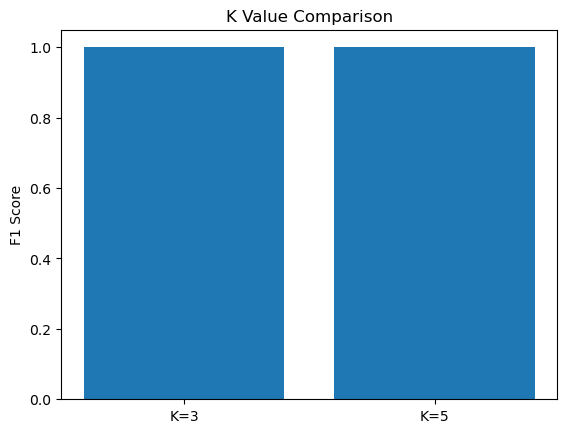

In [16]:
# Compare K=3 and K=5 performance# Compare K=3 and K=5 performance
plt.bar(['K=3', 'K=5'], [f1_k3, f1_score(y_test, predictions, average='weighted')])
plt.title("K Value Comparison")
plt.ylabel("F1 Score")
plt.show()